Build a Linear Regression model to predict a student's Exam_Score using:
    Study_Hours
    Attendance
    Assignments_Completed
Requirements
    Load the dataset.
    Split data into training and testing sets (80:20).
    Train a Linear Regression model.
    Predict Exam_Score on test data.
Calculate:
    MAE
    MSE
    RMSE
    R² Score

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv(r"C:\Users\eromn\Downloads\Regression_Dataset_1000.csv")

print(df.head())

# ==========================================
# Features and Target
# ==========================================

X = df[
    [
        "Study_Hours",
        "Attendance",
        "Assignments_Completed"
    ]
]

y = df["Exam_Score"]

# ==========================================
# Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ==========================================
# Train Model
# ==========================================

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

# ==========================================
# Prediction
# ==========================================

y_pred = model.predict(X_test)

# ==========================================
# Evaluation
# ==========================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("\nMAE =", mae)
print("MSE =", mse)
print("RMSE =", rmse)
print("R2 Score =", r2)

# ==========================================
# Actual vs Predicted
# ==========================================

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(results.head())

   Study_Hours  Attendance  Assignments_Completed  Exam_Score
0          6.8        51.3                      9       62.29
1          2.3        55.1                     18       55.77
2          4.8        51.5                      7       48.10
3          6.4        78.1                     18       89.82
4          5.0        63.9                      1       51.35

MAE = 4.858862511564996
MSE = 32.067567224731484
RMSE = 5.66282325565009
R2 Score = 0.9095475926512209
     Actual  Predicted
521   30.57  38.004657
737   76.98  72.907285
740   55.49  62.583274
660   81.46  74.247568
411   94.86  88.130682


Compare the performance of:

Linear Regression
Decision Tree Regressor
Random Forest Regressor
K-Nearest Neighbors Regressor

for predicting Exam Score

               Model       MAE      RMSE  R2 Score
0  Linear Regression  4.858863  5.662823  0.909548
1      Decision Tree  7.050700  8.440757  0.799037
2      Random Forest  5.465538  6.401261  0.884419
3                KNN  5.821410  6.985411  0.862362

Best RMSE Model
Model       Linear Regression
MAE                  4.858863
RMSE                 5.662823
R2 Score             0.909548
Name: 0, dtype: object

Best R2 Model
Model       Linear Regression
MAE                  4.858863
RMSE                 5.662823
R2 Score             0.909548
Name: 0, dtype: object


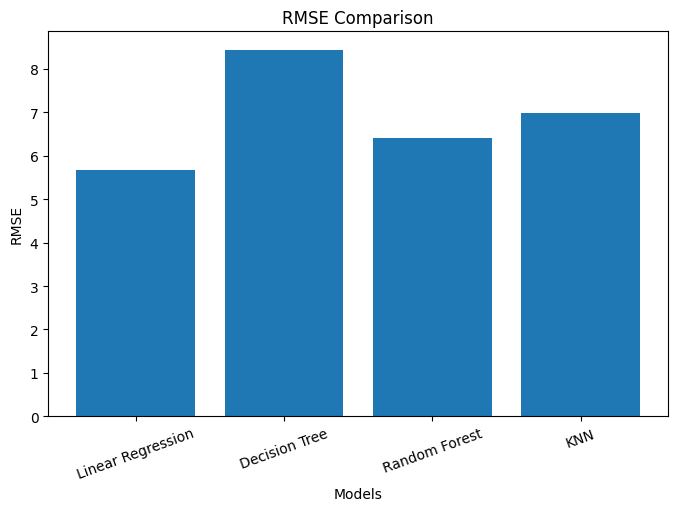

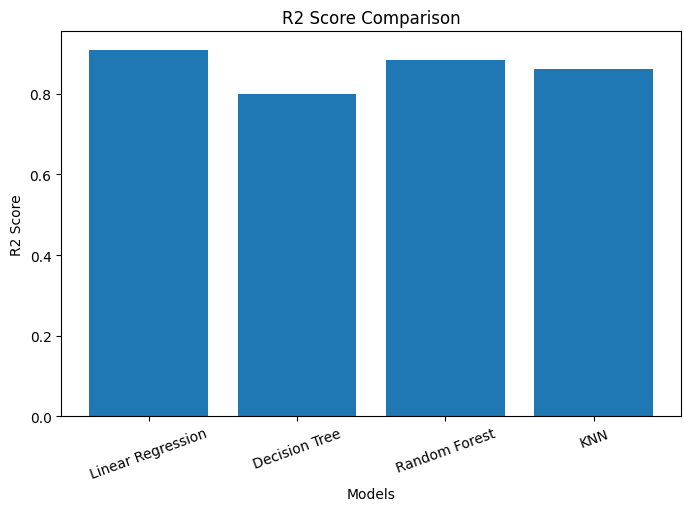

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv(
    r"C:\Users\eromn\Downloads\Regression_Dataset_1000.csv"
)

# ==========================================
# Features and Target
# ==========================================

X = df[
    [
        "Study_Hours",
        "Attendance",
        "Assignments_Completed"
    ]
]

y = df["Exam_Score"]

# ==========================================
# Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ==========================================
# Models
# ==========================================

models = {

    "Linear Regression":
    LinearRegression(),

    "Decision Tree":
    DecisionTreeRegressor(),

    "Random Forest":
    RandomForestRegressor(),

    "KNN":
    KNeighborsRegressor()

}

# ==========================================
# Train + Evaluate
# ==========================================

results = []

for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    results.append([
        name,
        mae,
        rmse,
        r2
    ])

# ==========================================
# Results DataFrame
# ==========================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)

print(results_df)

# ==========================================
# Best Models
# ==========================================

best_rmse = results_df.loc[
    results_df["RMSE"].idxmin()
]

best_r2 = results_df.loc[
    results_df["R2 Score"].idxmax()
]

print("\nBest RMSE Model")
print(best_rmse)

print("\nBest R2 Model")
print(best_r2)

# ==========================================
# RMSE Comparison
# ==========================================

plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.title(
    "RMSE Comparison"
)

plt.xlabel("Models")
plt.ylabel("RMSE")

plt.xticks(rotation=20)

plt.show()

# ==========================================
# R2 Comparison
# ==========================================

plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["R2 Score"]
)

plt.title(
    "R2 Score Comparison"
)

plt.xlabel("Models")
plt.ylabel("R2 Score")

plt.xticks(rotation=20)

plt.show()